In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
from collections import Counter
import random
import sys
sys.path.insert(0, '/cosma/home/dp004/dc-zhan5')
import MyHaloPS as ps
import importlib
importlib.reload(ps)

<module 'MyHaloPS' from '/cosma/home/dp004/dc-zhan5/MyHaloPS.py'>

In [2]:
plt.rcParams["xtick.direction"] = "in"
plt.rcParams["ytick.direction"] = "in"
plt.rc("font", family="STIXGeneral", size=18)
plt.rcParams["mathtext.fontset"] = "stix"
plt.rcParams['figure.figsize'] = (2*10/3, 4)
plt.rcParams["legend.frameon"] = False


plt.rcParams["xtick.major.size"] = 5
plt.rcParams["ytick.major.size"] = 5
plt.rcParams["ytick.minor.visible"] = True
plt.rcParams["xtick.minor.visible"] = True
plt.rcParams["xtick.top"] = True
plt.rcParams["ytick.right"] = True
plt.rcParams["lines.linewidth"] = 2
from matplotlib.lines import Line2D

In [3]:
fontsize=12
boxsize = 205

In [4]:
snapnum = 40

In [5]:
base_dir = f"/cosma7/data/dp004/dc-zhan5/TNG/snap{snapnum}/SubhaloFlag_all"
#ihalo_dir = f"{base_dir}/ihalo"
ihalo_dir = f"{base_dir}/mvir/ihalo"

### Read data for groups

In [6]:
#tng_dir3 = f"/cosma7/data/dp004/dc-zhan5/TNG/snap{snapnum}/mvir/ihalo/rvir"
#tng_dir3 = f"/cosma7/data/dp004/dc-zhan5/TNG/snap{snapnum}/ihalo"
tng_data_sum = np.loadtxt(f"{ihalo_dir}/sfr-halomass_sum.txt")


In [7]:
mask_min_sum = tng_data_sum[:,1] > 10
ihalo_tng_sum = tng_data_sum[:,0][mask_min_sum]
mhalo_tng_sum = tng_data_sum[:,1][mask_min_sum]
pos_tng_sum = tng_data_sum[:,2:5][mask_min_sum]
sfr_tng_sum = tng_data_sum[:,5][mask_min_sum]

Read zero SFR halos

In [8]:
tng_data_sum0 = np.loadtxt(f"{ihalo_dir}/sfr-halomass_sum.txt")

In [9]:
mask_min_sum0 = tng_data_sum0[:,1] > 10
ihalo_tng_sum0 = tng_data_sum0[:,0][mask_min_sum0]
mhalo_tng_sum0 = tng_data_sum0[:,1][mask_min_sum0]
pos_tng_sum0 = tng_data_sum0[:,2:5][mask_min_sum0]
sfr_tng_sum0 = tng_data_sum0[:,5][mask_min_sum0]

In [10]:
ihalo_tng3 = np.concatenate((ihalo_tng_sum, ihalo_tng_sum0))
mhalo_tng3 = np.concatenate((mhalo_tng_sum, mhalo_tng_sum0))
pos_tng3 = np.concatenate((pos_tng_sum, pos_tng_sum0))
sfr_tng3 = np.concatenate((sfr_tng_sum, sfr_tng_sum0))

Masks

In [11]:
mask = False
if mask is True:
    mask_min3 = (mhalo_tng3 > 10) & (pos_tng3[:,2] < 30) 
else:
    mask_min3 = mhalo_tng3 > 0

In [12]:
binned_all = ps.bin_data(ihalo_tng3, mhalo_tng3, pos_tng3, sfr_tng3)

dlogM =  0.1


/cosma/home/dp004/dc-zhan5/nbodykit_venv/lib/python3.12/site-packages/numpy/core/fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/cosma/home/dp004/dc-zhan5/nbodykit_venv/lib/python3.12/site-packages/numpy/core/_methods.py:129: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/cosma/home/dp004/dc-zhan5/nbodykit_venv/lib/python3.12/site-packages/numpy/core/_methods.py:206: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/cosma/home/dp004/dc-zhan5/nbodykit_venv/lib/python3.12/site-packages/numpy/core/_methods.py:163: RuntimeWarning: invalid value encountered in divide
  arrmean = um.true_divide(arrmean, div, out=arrmean,
/cosma/home/dp004/dc-zhan5/nbodykit_venv/lib/python3.12/site-packages/numpy/core/_methods.py:198: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


/cosma/home/dp004/dc-zhan5/MyHaloPS.py:1890: RuntimeWarning: invalid value encountered in scalar divide
  hods.append(Nnonzero/Ntot)


In [13]:
a1 = 1.8
b1 = -20.5
y = a1*12 + b1
print(y)
a2 = 0.7
b2 = y - a2*12
print(b2)
b2 = -7.3
print(b2)
y = a2*12 + b2
print(y)

1.1000000000000014
-7.299999999999997
-7.3
1.0999999999999988


In [14]:
poly_low = np.poly1d((a1,b1))
poly_high = np.poly1d((a2,b2))

In [15]:
import os


sfr_binned = binned_all["sfr"]
mhalo_binned = binned_all["mhalo"]
pos_binned = binned_all["pos"]

mhalos = np.concatenate(mhalo_binned)
pos = np.concatenate(pos_binned)
tng_sfrs = np.concatenate(sfr_binned)

sigma = False
sigma_low=0.4
sigma_high =0.2


if sigma is False:
    odir = f"/cosma8/data/dp004/dc-zhan5/invented/2sigma/{sigma_low}_{sigma_high}"
else:
    odir = f"/cosma8/data/dp004/dc-zhan5/invented/sigma{sigma}"
    sigma_low = sigma
    sigma_high = sigma
    
#odir1 = f"/cosma7/data/dp004/dc-zhan5/assignment_schemes/gaussian/tng_median/nonzero/sigma={sigma}"

is_tng_sfrs = False
is_mean = True
match_sfr_func = False

mhalo_change = 12

is_print = False

new_sfrs_list = []

if is_print:
    if not os.path.exists(odir):
        os.makedirs(odir)
        
shot_list = []
means_list = []

for fiducial_seed in range(0,1):
    np.random.seed(fiducial_seed)
    
    
    new_sfr_binned = []
    new_means = []
    new_mhalo_binned = []
    new_pos_binned = []
    
    
    
    #f_group = open(f"{odir}/logM<{logM}/seed{seed}.txt", "w")

    for ibin in range(len(mhalo_binned)):
        #sigma = stds[ibin]
        
        if len(mhalo_binned[ibin]) > 0:
            mask_low = mhalo_binned[ibin] < mhalo_change
            mask_high = mhalo_binned[ibin] > mhalo_change

            
            sfr_orig_low = np.random.normal(ps.Moster_sfr_mhalo(mhalo_binned[ibin][mask_low]), sigma_low)
            sfr_orig_high = np.random.normal(ps.Moster_sfr_mhalo(mhalo_binned[ibin][mask_high]), sigma_high)

            sfr_orig = np.concatenate((sfr_orig_low, sfr_orig_high))

            new_sfr_binned.append(sfr_orig)

           
            mean = np.log10(np.mean(10**sfr_orig))
            new_means.append(mean)
            
            new_mhalo_binned.append(np.concatenate((mhalo_binned[ibin][mask_low], mhalo_binned[ibin][mask_high])))
            new_pos_binned.append(np.concatenate((pos_binned[ibin][mask_low], pos_binned[ibin][mask_high])))

                
        else:
            new_means.append(np.nan)
            new_sfr_binned.append([])
            new_mhalo_binned.append([])
            new_pos_binned.append([])
   
    new_sfrs = np.concatenate(new_sfr_binned)
    shotnoise = ps.compute_shotnoise(10**new_sfrs, 205,3)
    shot_list.append(shotnoise)
    mean_sfr = np.mean(10**new_sfrs)
    means_list.append(mean_sfr)
    new_mhalos = np.concatenate(new_mhalo_binned)

    
    new_sfrs_list.append(new_sfrs)
    
    if match_sfr_func:
        sorted_new_sfr_indices = np.flip(np.argsort(new_sfrs)) 

        mhalos_renormed = mhalos[sorted_new_sfr_indices]
        pos_renormed = pos[sorted_new_sfr_indices]
        if is_tng_sfrs:
            sfrs_renormed = np.flip(np.sort(tng_sfrs))
        else:
            sfrs_renormed = np.array(new_sfrs)[sorted_new_sfr_indices]
        
        f_renormed = open(f"{odir}/match_sfr_func/seed{seed}.txt", "w")
        print("# log10(mass[Msun/h]) x[Mpc/h] y[Mpc/h] z[Mpc/h] log10(sfr[Msun/yr])", file=f_renormed)
      
        for ihalo in range(len(mhalos_renormed)):
            print(mhalos_renormed[ihalo], pos_renormed[ihalo][0], pos_renormed[ihalo][1], pos_renormed[ihalo][2], sfrs_renormed[ihalo], file=f_renormed)
        f_renormed.close()
    else:
        if is_mean:
            fname = f"{odir}/seed{fiducial_seed}_mean.txt"
        else:
            fname = f"{odir}/seed{fiducial_seed}.txt"
        
        if is_print:
            f_group = open(fname, "w")
            print("# log10(mass[Msun/h]) x[Mpc/h] y[Mpc/h] z[Mpc/h] log10(sfr[Msun/yr])", file=f_group)
 
            for ibin in range(len(mhalo_binned)):
                if len(sfr_binned[ibin]) > 0:
                    for ihalo in range(len(sfr_binned[ibin])):
                        if is_mean:
                            sfr = new_means[ibin]
                        else:
                            sfr = new_sfr_binned[ibin][ihalo]
                    
                        print(new_mhalo_binned[ibin][ihalo], new_pos_binned[ibin][ihalo][0], new_pos_binned[ibin][ihalo][1], new_pos_binned[ibin][ihalo][2], sfr , file=f_group)

            f_group.close()

      
    

In [16]:
L1 = 2.27 * 1e41
L1 = 2 * 1e41 * 10**-11 * 10**11.5
print(L1)
M =10**binned_all["mass_bins"]
M1 = 10**11.5
a = 1.7
b = 0.35

new_eq = 2 * L1 * (M/M1) * ((M/M1)**(-a) + (M/M1)**b)**-1
new_sfr_eq = new_eq/(2*10**41)


6.324555320336758e+41


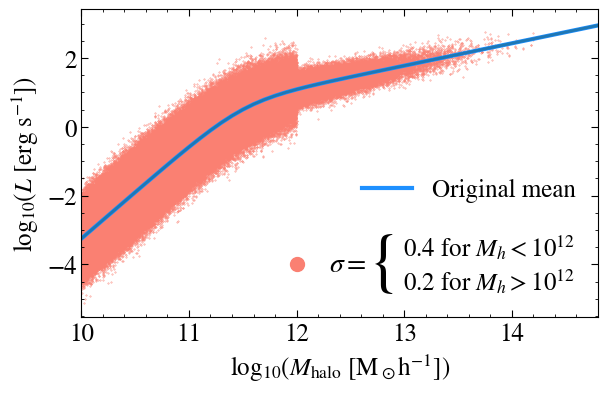

<Figure size 666.667x400 with 0 Axes>

In [17]:
import matplotlib.transforms as mtrans
from matplotlib.text import TextPath
from matplotlib.patches import PathPatch

fig,ax = plt.subplots()
#plt.scatter(new_mhalos, new_sfrs, s=0.1,  color="skyblue", label="$\sigma$ = 0.2")
ax.scatter(new_mhalos, new_sfrs, s=0.1,  color="salmon")



ax.plot(binned_all["mass_bins"], ps.Moster_sfr_mhalo(binned_all["mass_bins"]), label="Original mean", color="DodgerBlue", linewidth=3)

#ax.plot(binned_all["mass_bins"], new_means, label="New mean", color="purple", linewidth=3)


legend = ax.legend(markerscale=30, loc="lower right",bbox_to_anchor=(1,0.3))




# ax.annotate(r"$\rm \sigma = $",fontsize=20,
#             xy=(0.55, 0.315), xycoords="figure fraction", textcoords=offset
#             )
ax.plot(12,-4, "o", markersize=10, c="salmon")
ax.annotate(r"$\sigma = $",fontsize=20,
            xy=(12.3,-4), va="center"
           )
ax.annotate(r"$\{$",fontsize=50,
            xy=(12.65, -4),  va="center"
           )
ax.annotate(r"$\rm \quad\quad\ 0.4\ for\ $" + "$M_h$" + "$ < 10^{12}$"+ "\n" +r"$\rm\quad\quad\ 0.2\ for\ $" + "$M_h$" + "$ > 10^{12}$",
            fontsize=18, xy=(12.6, -4), va="center"
           )

    
# offset = mpl.text.OffsetFrom(legend, (0.3, 0.33))
# ax.annotate(r"$\rm \sigma = $", xy=(1,1),size=20,
#             xycoords='figure fraction', xytext=(1,1), textcoords=offset,
#             horizontalalignment='right', verticalalignment='top')


def curly(x,y, scale, ax=None):
    if not ax: ax=plt.gca()
    tp = TextPath((0, 0), "{", size=1)
    trans = mtrans.Affine2D().scale(0.3, scale) + \
        mtrans.Affine2D().translate(x,y) + ax.transData
    pp = PathPatch(tp, lw=0, fc="k", transform=trans)
    ax.add_artist(pp)
#curly(12.8,-4.3,2, ax)

plt.plot(binned_all["mass_bins"], np.log10(np.array(new_sfr_eq,dtype=float)))


plt.xlabel(r"log$_{10}(M_{\rm halo}$ [M$_\odot$h$^{-1}$])")
plt.ylabel('log$_{10}$($L$ [erg s$^{-1}$])')
plt.xlim(10,14.8)
#plt.savefig("../figures/invented_sigma=0.4_0.2_orig_mean.png", format="png", bbox_inches="tight", dpi=300)
plt.show()
plt.clf()

<>:55: SyntaxWarning: invalid escape sequence '\o'
<>:55: SyntaxWarning: invalid escape sequence '\o'
/tmp/ipykernel_2207168/1202878844.py:55: SyntaxWarning: invalid escape sequence '\o'
  plt.ylabel('log$_{10}$($SFR$ [M$_\odot$ yr$^{-1}$])')


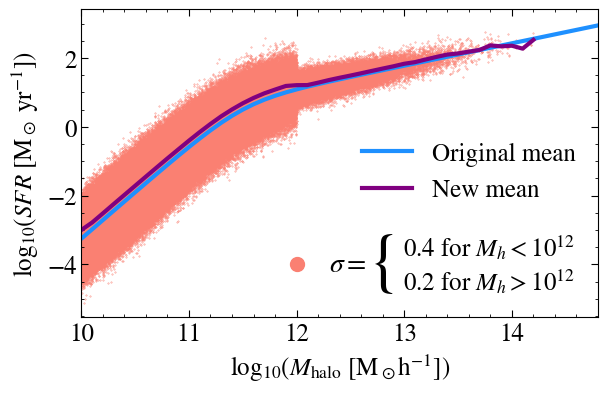

<Figure size 666.667x400 with 0 Axes>

In [18]:
import matplotlib.transforms as mtrans
from matplotlib.text import TextPath
from matplotlib.patches import PathPatch

fig,ax = plt.subplots()
#plt.scatter(new_mhalos, new_sfrs, s=0.1,  color="skyblue", label="$\sigma$ = 0.2")
ax.scatter(new_mhalos, new_sfrs, s=0.1,  color="salmon")



ax.plot(binned_all["mass_bins"], ps.Moster_sfr_mhalo(binned_all["mass_bins"]), label="Original mean", color="DodgerBlue", linewidth=3)

ax.plot(binned_all["mass_bins"], new_means, label="New mean", color="purple", linewidth=3)


legend = ax.legend(markerscale=30, loc="lower right",bbox_to_anchor=(1,0.3))




# ax.annotate(r"$\rm \sigma = $",fontsize=20,
#             xy=(0.55, 0.315), xycoords="figure fraction", textcoords=offset
#             )
ax.plot(12,-4, "o", markersize=10, c="salmon")
ax.annotate(r"$\sigma = $",fontsize=20,
            xy=(12.3,-4), va="center"
           )
ax.annotate(r"$\{$",fontsize=50,
            xy=(12.65, -4),  va="center"
           )
ax.annotate(r"$\rm \quad\quad\ 0.4\ for\ $" + "$M_h$" + "$ < 10^{12}$"+ "\n" +r"$\rm\quad\quad\ 0.2\ for\ $" + "$M_h$" + "$ > 10^{12}$",
            fontsize=18, xy=(12.6, -4), va="center"
           )

    
# offset = mpl.text.OffsetFrom(legend, (0.3, 0.33))
# ax.annotate(r"$\rm \sigma = $", xy=(1,1),size=20,
#             xycoords='figure fraction', xytext=(1,1), textcoords=offset,
#             horizontalalignment='right', verticalalignment='top')


def curly(x,y, scale, ax=None):
    if not ax: ax=plt.gca()
    tp = TextPath((0, 0), "{", size=1)
    trans = mtrans.Affine2D().scale(0.3, scale) + \
        mtrans.Affine2D().translate(x,y) + ax.transData
    pp = PathPatch(tp, lw=0, fc="k", transform=trans)
    ax.add_artist(pp)
#curly(12.8,-4.3,2, ax)




plt.xlabel(r"log$_{10}(M_{\rm halo}$ [M$_\odot$h$^{-1}$])")
plt.ylabel('log$_{10}$($SFR$ [M$_\odot$ yr$^{-1}$])')
plt.xlim(10,14.8)
#plt.savefig("../figures/invented_sigma=0.4_0.2_orig_mean.png", format="png", bbox_inches="tight", dpi=300)
plt.show()
plt.clf()

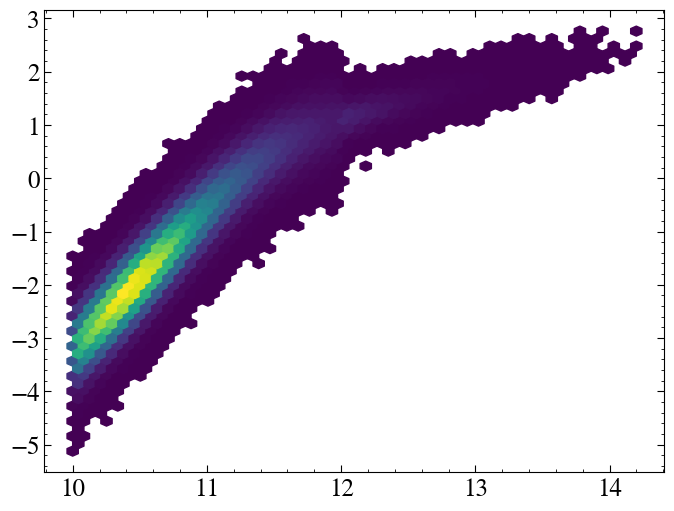

In [19]:
# Create 2D histogram
bins = 100  # Number of bins for density calculation
density, xedges, yedges = np.histogram2d(new_mhalos, new_sfrs, bins=bins, density=True)

# Map density to colors
x_centers = 0.5 * (xedges[:-1] + xedges[1:])
y_centers = 0.5 * (yedges[:-1] + yedges[1:])
X, Y = np.meshgrid(x_centers, y_centers)

# Plot scatter with colors based on density
plt.figure(figsize=(8, 6))
plt.hexbin(new_mhalos, new_sfrs, gridsize=50, cmap='viridis', mincnt=1)

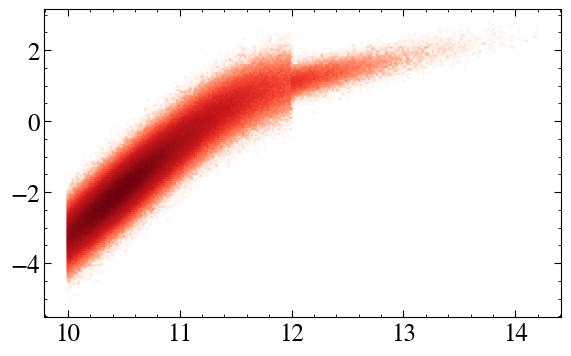

In [20]:
# vmin = np.percentile(density, 5)  # Clip the lowest 5%
# vmax = np.percentile(density, 95)  # Clip the highest 5%
from matplotlib.colors import LogNorm
plt.hexbin(new_mhalos, new_sfrs, gridsize=250, cmap='Reds', norm=LogNorm(),mincnt=1)

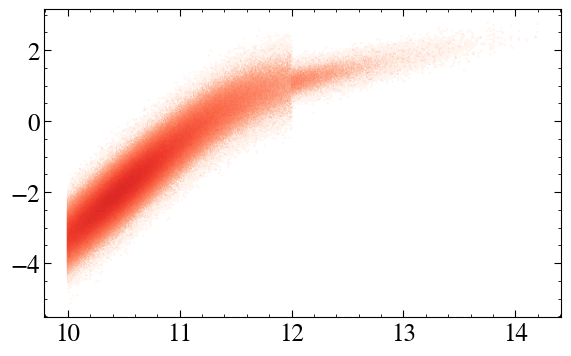

In [21]:
from matplotlib.colors import LinearSegmentedColormap
from matplotlib import cm  # Import cm for colormap handling

# Define the colormap
cmap = cm.Reds

# Extract a subset of the colormap
cmap_subset = LinearSegmentedColormap.from_list(
    'Reds', cmap(np.linspace(0.01, 0.7, 256))
)

plt.hexbin(new_mhalos, new_sfrs, gridsize=500, cmap=cmap_subset, norm=LogNorm(),mincnt=1)

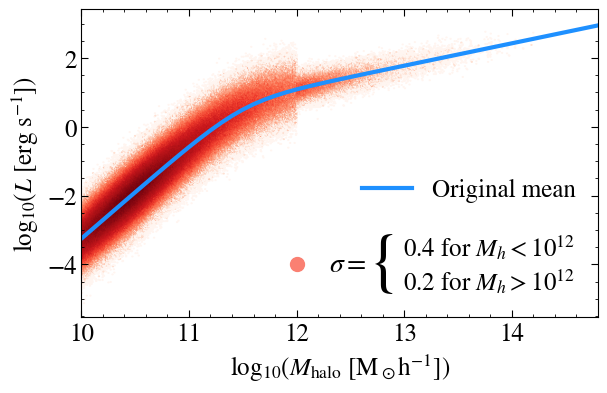

<Figure size 666.667x400 with 0 Axes>

In [22]:
import matplotlib.transforms as mtrans
from matplotlib.text import TextPath
from matplotlib.patches import PathPatch

fig,ax = plt.subplots()
#plt.scatter(new_mhalos, new_sfrs, s=0.1,  color="skyblue", label="$\sigma$ = 0.2")
#ax.scatter(new_mhalos, new_sfrs, c=density, s=0.1,  color="salmon")

plt.hexbin(new_mhalos, new_sfrs, gridsize=500, cmap='Reds', norm=LogNorm(),mincnt=1)

ax.plot(binned_all["mass_bins"], ps.Moster_sfr_mhalo(binned_all["mass_bins"]), label="Original mean", color="DodgerBlue", linewidth=3)

#ax.plot(binned_all["mass_bins"], new_means, label="New mean", color="purple", linewidth=3)


legend = ax.legend(markerscale=30, loc="lower right",bbox_to_anchor=(1,0.3))




# ax.annotate(r"$\rm \sigma = $",fontsize=20,
#             xy=(0.55, 0.315), xycoords="figure fraction", textcoords=offset
#             )
ax.plot(12,-4, "o", markersize=10, c="salmon")
ax.annotate(r"$\sigma = $",fontsize=20,
            xy=(12.3,-4), va="center"
           )
ax.annotate(r"$\{$",fontsize=50,
            xy=(12.65, -4),  va="center"
           )
ax.annotate(r"$\rm \quad\quad\ 0.4\ for\ $" + "$M_h$" + "$ < 10^{12}$"+ "\n" +r"$\rm\quad\quad\ 0.2\ for\ $" + "$M_h$" + "$ > 10^{12}$",
            fontsize=18, xy=(12.6, -4), va="center"
           )

    
# offset = mpl.text.OffsetFrom(legend, (0.3, 0.33))
# ax.annotate(r"$\rm \sigma = $", xy=(1,1),size=20,
#             xycoords='figure fraction', xytext=(1,1), textcoords=offset,
#             horizontalalignment='right', verticalalignment='top')


def curly(x,y, scale, ax=None):
    if not ax: ax=plt.gca()
    tp = TextPath((0, 0), "{", size=1)
    trans = mtrans.Affine2D().scale(0.3, scale) + \
        mtrans.Affine2D().translate(x,y) + ax.transData
    pp = PathPatch(tp, lw=0, fc="k", transform=trans)
    ax.add_artist(pp)
#curly(12.8,-4.3,2, ax)




plt.xlabel(r"log$_{10}(M_{\rm halo}$ [M$_\odot$h$^{-1}$])")
plt.ylabel('log$_{10}$($L$ [erg s$^{-1}$])')
plt.xlim(10,14.8)
#plt.savefig("../figures/invented_sigma=0.4_0.2_orig_mean_density.png", format="png", bbox_inches="tight", dpi=300)
plt.show()
plt.clf()

<>:10: SyntaxWarning: invalid escape sequence '\p'
<>:10: SyntaxWarning: invalid escape sequence '\p'
/tmp/ipykernel_2207168/1667213753.py:10: SyntaxWarning: invalid escape sequence '\p'
  ax.plot(binned_all["mass_bins"][mask_low], ps.Moster_sfr_mhalo(binned_all["mass_bins"][mask_low])+0.4, color="DodgerBlue", linewidth=1, linestyle="dashed",label="mean $\pm\ \sigma$",)


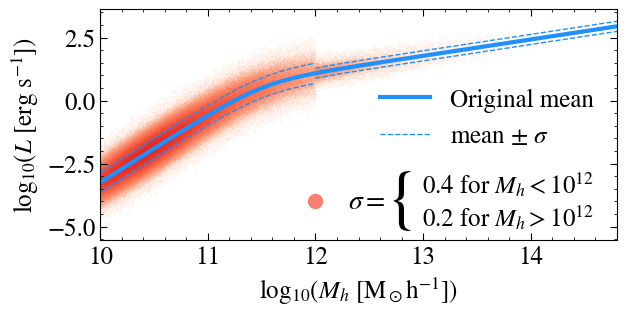

<Figure size 666.667x400 with 0 Axes>

In [27]:
fig,ax = plt.subplots(figsize=(2*10/3, 3))

#plt.hexbin(new_mhalos, new_sfrs, gridsize=500, cmap='Reds', norm=LogNorm(),mincnt=1)

plt.hexbin(new_mhalos, new_sfrs, gridsize=500, cmap=cmap_subset, norm=LogNorm(),mincnt=1)

ax.plot(binned_all["mass_bins"], ps.Moster_sfr_mhalo(binned_all["mass_bins"]), label="Original mean", color="DodgerBlue", linewidth=3)

mask_low = binned_all["mass_bins"]<= 12
ax.plot(binned_all["mass_bins"][mask_low], ps.Moster_sfr_mhalo(binned_all["mass_bins"][mask_low])+0.4, color="DodgerBlue", linewidth=1, linestyle="dashed",label="mean $\pm\ \sigma$",)
ax.plot(binned_all["mass_bins"][mask_low], ps.Moster_sfr_mhalo(binned_all["mass_bins"][mask_low])-0.4, color="DodgerBlue", linewidth=1, linestyle="dashed")
mask_low = binned_all["mass_bins"]>= 12
ax.plot(binned_all["mass_bins"][mask_low], ps.Moster_sfr_mhalo(binned_all["mass_bins"][mask_low])+0.2, color="DodgerBlue", linewidth=1, linestyle="dashed")
ax.plot(binned_all["mass_bins"][mask_low], ps.Moster_sfr_mhalo(binned_all["mass_bins"][mask_low])-0.2, color="DodgerBlue", linewidth=1, linestyle="dashed")

legend = ax.legend(markerscale=30, loc="lower right",bbox_to_anchor=(1,0.3))

ax.plot(12,-4, "o", markersize=10, c="salmon")
ax.annotate(r"$\sigma = $",fontsize=20,
            xy=(12.3,-4), va="center"
           )
ax.annotate(r"$\{$",fontsize=50,
            xy=(12.65, -4),  va="center"
           )
ax.annotate(r"$\rm \quad\quad\ 0.4\ for\ $" + "$M_h$" + "$ < 10^{12}$"+ "\n" +r"$\rm\quad\quad\ 0.2\ for\ $" + "$M_h$" + "$ > 10^{12}$",
            fontsize=18, xy=(12.6, -4), va="center"
           )

def curly(x,y, scale, ax=None):
    if not ax: ax=plt.gca()
    tp = TextPath((0, 0), "{", size=1)
    trans = mtrans.Affine2D().scale(0.3, scale) + \
        mtrans.Affine2D().translate(x,y) + ax.transData
    pp = PathPatch(tp, lw=0, fc="k", transform=trans)
    ax.add_artist(pp)




plt.xlabel(r"log$_{10}(M_h$ [M$_\odot$h$^{-1}$])")
plt.ylabel('log$_{10}$($L$ [erg s$^{-1}$])')
plt.xlim(10,14.8)
#plt.savefig("../figures/invented_sigma=0.4_0.2_orig_mean_density_w_sigma.png", format="png", bbox_inches="tight", dpi=300)
plt.show()
plt.clf()

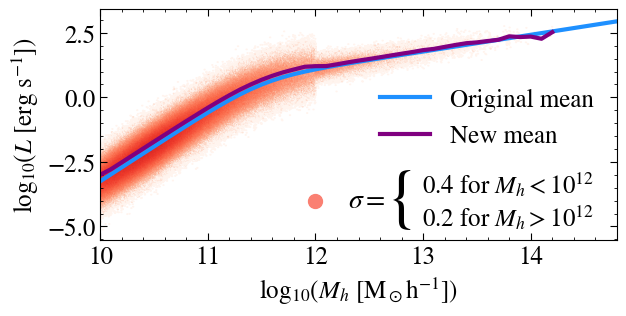

<Figure size 666.667x400 with 0 Axes>

In [26]:
import matplotlib.transforms as mtrans
from matplotlib.text import TextPath
from matplotlib.patches import PathPatch

fig,ax = plt.subplots(figsize=(2*10/3, 3))
#plt.scatter(new_mhalos, new_sfrs, s=0.1,  color="skyblue", label="$\sigma$ = 0.2")
#ax.scatter(new_mhalos, new_sfrs, s=0.1,  color="salmon")

#plt.hexbin(new_mhalos, new_sfrs, gridsize=500, cmap='Reds', norm=LogNorm(),mincnt=1)

plt.hexbin(new_mhalos, new_sfrs, gridsize=500, cmap=cmap_subset, norm=LogNorm(),mincnt=1)


ax.plot(binned_all["mass_bins"], ps.Moster_sfr_mhalo(binned_all["mass_bins"]), label="Original mean", color="DodgerBlue", linewidth=3)

ax.plot(binned_all["mass_bins"], new_means, label="New mean", color="purple", linewidth=3)


legend = ax.legend(markerscale=30, loc="lower right",bbox_to_anchor=(1,0.3))



ax.plot(12,-4, "o", markersize=10, c="salmon")
ax.annotate(r"$\sigma = $",fontsize=20,
            xy=(12.3,-4), va="center"
           )
ax.annotate(r"$\{$",fontsize=50,
            xy=(12.65, -4),  va="center"
           )
ax.annotate(r"$\rm \quad\quad\ 0.4\ for\ $" + "$M_h$" + "$ < 10^{12}$"+ "\n" +r"$\rm\quad\quad\ 0.2\ for\ $" + "$M_h$" + "$ > 10^{12}$",
            fontsize=18, xy=(12.6, -4), va="center"
           )



def curly(x,y, scale, ax=None):
    if not ax: ax=plt.gca()
    tp = TextPath((0, 0), "{", size=1)
    trans = mtrans.Affine2D().scale(0.3, scale) + \
        mtrans.Affine2D().translate(x,y) + ax.transData
    pp = PathPatch(tp, lw=0, fc="k", transform=trans)
    ax.add_artist(pp)
#curly(12.8,-4.3,2, ax)




plt.xlabel(r"log$_{10}(M_h$ [M$_\odot$h$^{-1}$])")
plt.ylabel('log$_{10}$($L$ [erg s$^{-1}$])')
plt.xlim(10,14.8)
#plt.savefig("../figures/invented_sigma=0.4_0.2_new_mean.png", format="png", bbox_inches="tight", dpi=300)
plt.show()
plt.clf()